# Collider Ring Studies (twiss_ir1ccma_hybrid_v06).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt
from mint import beam_optics as bopt
from mint import const, xsecs
from mint.MuC import MuDecaySimulator
from mint import plot_tools as pt

import vector


## Create main collider-ring lattice

In [2]:

twiss_file = "beam-optics/twiss_ir1ccma_hybrid_v06.outx"

ring_df = lt.get_lattice_dataframe_from_tfs(twiss_file)
ring_dict = bopt.create_smoothed_lattice(
    ring_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
ring_lattice = lt.Lattice(**ring_dict)
ring_lattice.name = "twiss_ir1ccma_hybrid_v06"
ring_lattice.short_name = "ir1ccma_v06"

# Operation assumptions
ring_lattice.Nmu_per_bunch = 2e12
ring_lattice.finj = 5.0
ring_lattice.bunch_multiplicity = 1.0
ring_lattice.duty_factor = 1 / np.pi # 1e7 seconds per year

print(f"Lattice: {ring_lattice.name}")
print(f"Ring circumference: {ring_lattice.s(1)/1e3:.2f} km")

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae2b0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae300>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae3a0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x1773ae3f0>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae440>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x1773ae490>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae4e0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x1773ae530>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x1773ae580>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x1773ae5d0>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

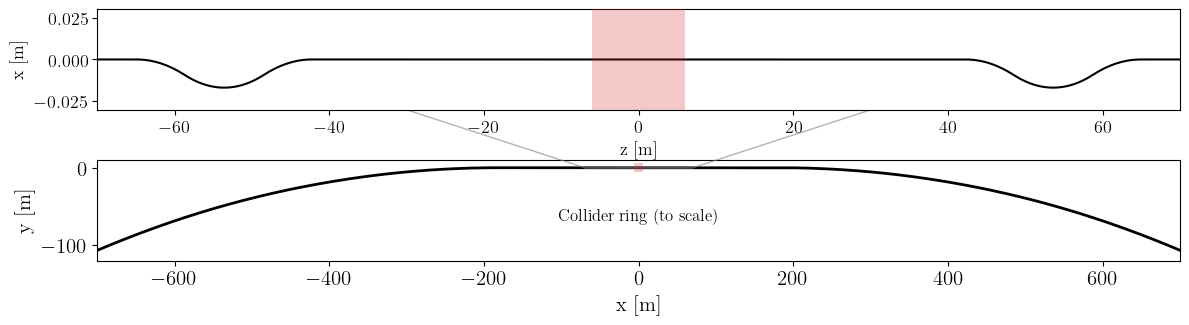

In [3]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2.0, color='black')
ax.set_xlabel("x [m]", fontsize=15)
ax.set_ylabel("y [m]", fontsize=15)
ax.tick_params(labelsize=15)
ax.text(0.5, 0.4, "Collider ring (to scale)", transform=ax.transAxes, ha="center", fontsize=12)
ax.set_xlim(-700, 700)
ax.set_ylim(-120, 10)
ax.set_aspect("equal", adjustable="box")

# Detector box: ±6 m around IP (0, 0)
det_half = 6  # meters
det_box = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                         linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
ax.add_patch(det_box)

# Inset: chicane detail at ~x=50m, y~20cm
xl = 0.12
axins = ax.inset_axes([0, 1.5, 1, 1])
axins.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=1.5, color='black')
axins.set_xlim(-70, 70)
axins.set_ylim(-0.03, 0.03)
axins.tick_params(labelsize=13)
axins.set_xlabel("z [m]", fontsize=13)
axins.set_ylabel("x [m]", fontsize=13)
ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.6)

# Detector box in inset
det_box_ins = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                              linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
axins.add_patch(det_box_ins)
# axins.set_aspect("equal", adjustable="box")

fig.tight_layout()
fig.savefig("plots/collider_ring_geometry.pdf", dpi=400)

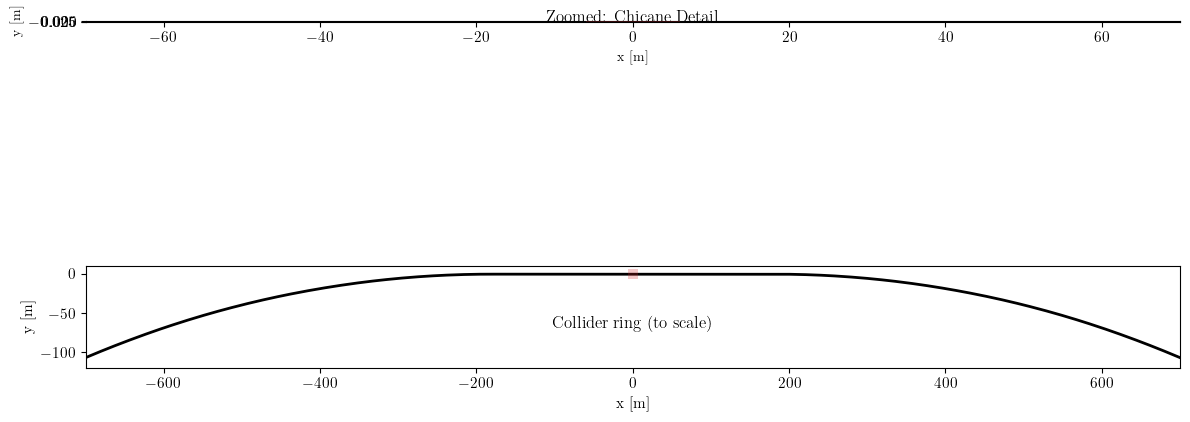

In [4]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, (ax_zoom, ax) = plt.subplots(2, 1, figsize=(12, 8))

# Zoomed in part (top)
ax_zoom.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=1.5, color='black')
ax_zoom.set_xlim(-70, 70)
ax_zoom.set_ylim(-0.03, 0.03)
ax_zoom.set_xlabel("x [m]", fontsize=10)
ax_zoom.set_ylabel("y [m]", fontsize=10)
ax_zoom.text(0.5, 0.85, "Zoomed: Chicane Detail", transform=ax_zoom.transAxes, ha="center", fontsize=12)

# Detector box in zoomed view
det_half = 6  # meters
det_box_ins = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                              linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
ax_zoom.add_patch(det_box_ins)
ax_zoom.set_aspect("equal", adjustable="box")

# Full ring (bottom)
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2.0, color='black')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.text(0.5, 0.4, "Collider ring (to scale)", transform=ax.transAxes, ha="center", fontsize=12)
ax.set_xlim(-700, 700)
ax.set_ylim(-120, 10)
ax.set_aspect("equal", adjustable="box")

# Detector box in full ring
det_box = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                         linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.25, zorder=5)
ax.add_patch(det_box)

fig.tight_layout()
fig.savefig("plots/collider_ring_geometry.pdf", dpi=400)

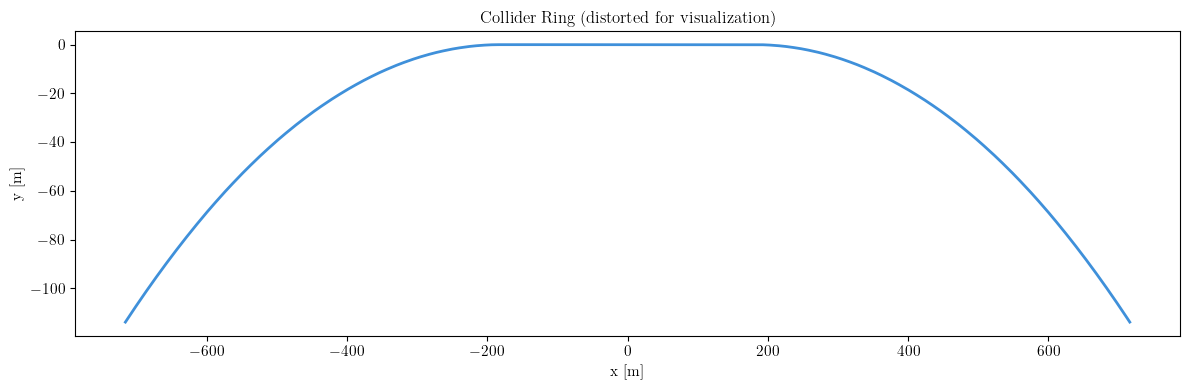

In [5]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider Ring (distorted for visualization)")
# ax.set_ylim(-0.1,0.01)
# ax.set_xlim(-200,200)
fig.tight_layout()

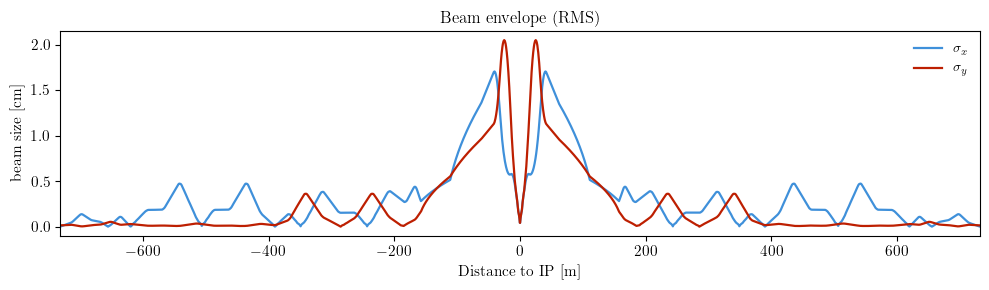

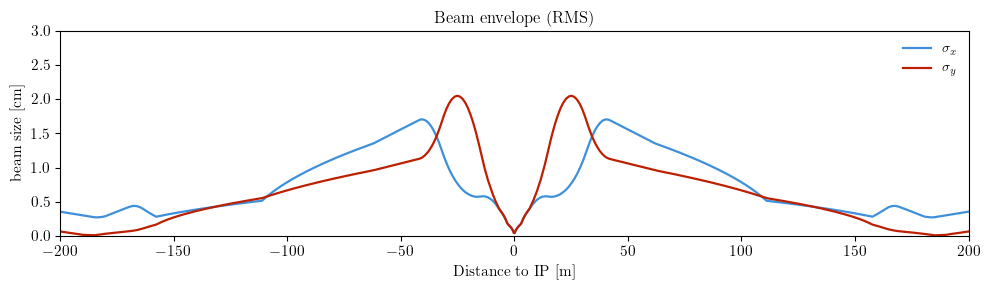

In [6]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x = ring_dict["beamsize_x"](u)
sigma_y = ring_dict["beamsize_y"](u)

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label=r"$\sigma_x$", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label=r"$\sigma_y$", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope.pdf", dpi=300, bbox_inches="tight")



fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label=r"$\sigma_x$", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label=r"$\sigma_y$", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_ylim(1e-3*0, 3)
#ax_env.set_yscale('log')
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope_zoomed.pdf", dpi=300, bbox_inches="tight")


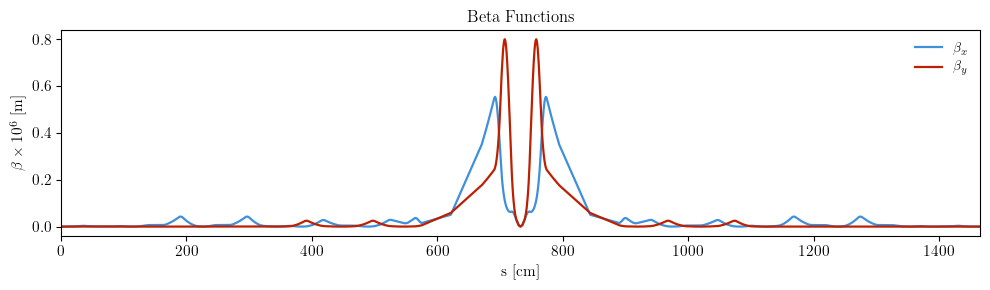

In [7]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
s_m = ring_lattice.s(u) * 1e-2
sigma_x = ring_dict["betx"](u) * 1e-6
sigma_y = ring_dict["bety"](u) * 1e-6

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(s_m, sigma_x, label=r"$\beta_x$", lw=1.6)
ax_env.plot(s_m, sigma_y, label=r"$\beta_y$", lw=1.6)
ax_env.set_xlabel(r"s [cm]")
ax_env.set_ylabel(r"$\beta \times 10^{6}$ [m]")
ax_env.set_title("Beta Functions")
ax_env.legend(frameon=False)
ax_env.set_xlim(s_m.min(), s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beta_functions.pdf", dpi=300, bbox_inches="tight")


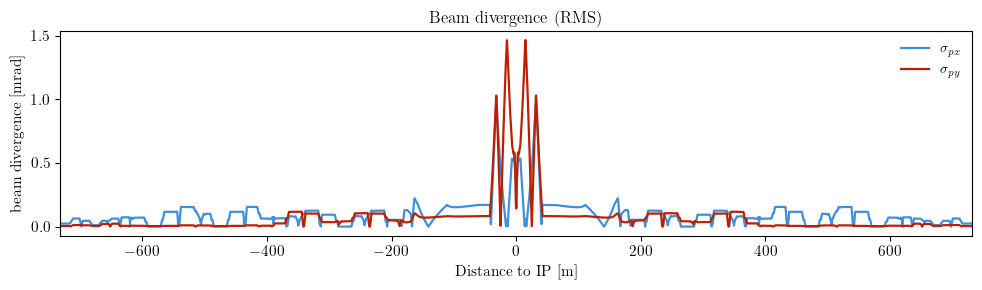

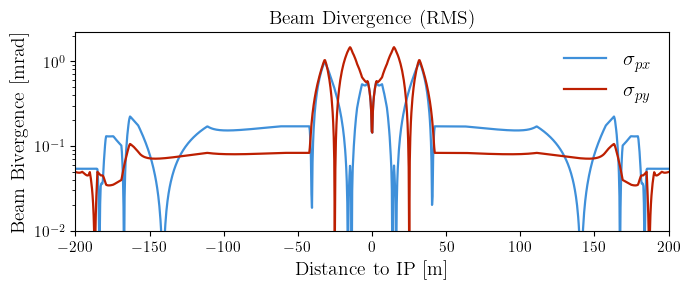

In [8]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"$\sigma_{px}$", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"$\sigma_{py}$", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence.pdf", dpi=300, bbox_inches="tight")

# ZOOMED IN
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(7, 3))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"$\sigma_{px}$", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"$\sigma_{py}$", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]", fontsize=14)
ax_env.set_ylabel("Beam Bivergence [mrad]", fontsize=14)
ax_env.set_title("Beam Divergence (RMS)", fontsize=14)
ax_env.legend(frameon=False, fontsize=15)
ax_env.set_yscale('log')
ax_env.set_ylim(0.01, None)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence_zoomed.pdf", dpi=300, bbox_inches="tight")

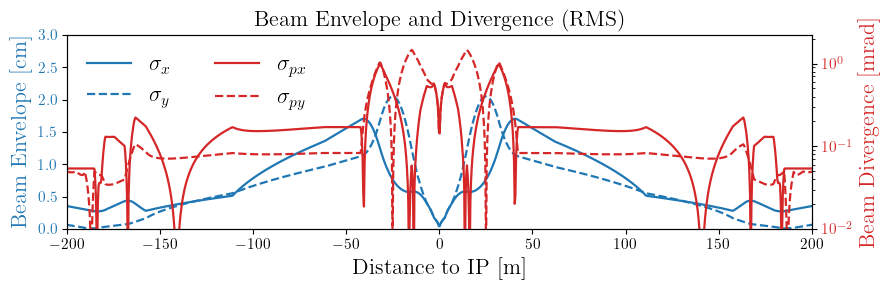

In [9]:


# Combined plot: beam envelope and divergence on same x-axis
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x = ring_dict["beamsize_x"](u)
sigma_y = ring_dict["beamsize_y"](u)
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig, ax1 = plt.subplots(figsize=(9, 3))

# Left y-axis: beam envelope
ax1.set_xlabel("Distance to IP [m]", fontsize=16)
ax1.set_ylabel("Beam Envelope [cm]", color='tab:blue', fontsize=16)
line1 = ax1.plot(delta_s_m, sigma_x, label=r"$\sigma_x$", lw=1.6, color='tab:blue', linestyle='-')
line2 = ax1.plot(delta_s_m, sigma_y, label=r"$\sigma_y$", lw=1.6, color='tab:blue', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(1e-3*0, 3)
ax1.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)

ax1.set_title("Beam Envelope and Divergence (RMS)",fontsize=16)

# Right y-axis: beam divergence
ax2 = ax1.twinx()
ax2.set_ylabel("Beam Divergence [mrad]", color='tab:red', fontsize=16)
line3 = ax2.plot(delta_s_m, sigma_x_mrad, label=r"$\sigma_{px}$", lw=1.6, color='tab:red', linestyle='-')
line4 = ax2.plot(delta_s_m, sigma_y_mrad, label=r"$\sigma_{py}$", lw=1.6, color='tab:red', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_yscale('log')
ax2.set_ylim(0.01, None)

# Combined legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=False, fontsize=16,ncols=2)

fig.tight_layout()
fig.savefig("plots/hybrid_v06_beam_envelope_and_divergence.pdf", dpi=300, bbox_inches="tight")
plt.show()



## Simulate forward neutrino flux

In [10]:
# ============================================================================
# CONSOLIDATED LATTICE, SIMULATION & RESULTS STORAGE
# ============================================================================
# This section creates all lattices, runs all simulations ONCE, and stores
# results in organized dictionaries for independent access.

# --- Define all lattices ---
lattices = {
    "ring": ring_lattice,  # Already created above
}

# Straight lattice
from mint import lattice_tools as lt
import pandas as pd
import copy

def make_straight_lattice_from_midpoint(df):
    """Create straight-line lattice from dataframe"""
    n = len(df)
    mid = n // 2
    def traverse(start, stop, step):
        out = []
        nonzero_count = 0
        for i in range(start, stop, step):
            row = df.iloc[i].copy()
            if row["ANGLE"] != 0:
                if nonzero_count < 3:
                    row["ANGLE"] = 0
                    nonzero_count += 1
                else:
                    break
            out.append(row)
        return out
    left = traverse(mid, -1, -1)
    right = traverse(mid+1, n, 1)
    new_rows = list(reversed(left)) + right
    new_df = pd.DataFrame(new_rows).reset_index(drop=True)
    new_df["ANGLE"] = 0
    new_df["px"] = np.sqrt(new_df["px"]**2 + new_df["py"]**2)
    new_df["py"] = 0.0
    new_df.attrs = df.attrs.copy()
    return new_df

def make_curved_lattice_with_zero_chicanes(df):
    """Create curved lattice with chicanes removed"""
    n = len(df)
    mid = n // 2
    def traverse(start, stop, step):
        out = []
        nonzero_count = 0
        for i in range(start, stop, step):
            row = df.iloc[i].copy()
            if row["ANGLE"] != 0:
                if nonzero_count < 3:
                    row["ANGLE"] = 0
                    nonzero_count += 1
            out.append(row)
        return out
    left = traverse(mid, -1, -1)
    right = traverse(mid+1, n, 1)
    new_rows = list(reversed(left)) + right
    new_df = pd.DataFrame(new_rows).reset_index(drop=True)
    new_df.attrs = df.attrs.copy()
    return new_df

# Create straight lattice
straight_df = make_straight_lattice_from_midpoint(ring_df)
straight_dict = bopt.create_smoothed_lattice(
    straight_df,
    emittance_RMS=25e-6/(5e3/0.105),
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
straight_lattice = lt.Lattice(**straight_dict)
straight_lattice.name = "straightened_lattice"
straight_lattice.Nmu_per_bunch = 2e12
straight_lattice.finj = 5.0
straight_lattice.bunch_multiplicity = 1.0
straight_lattice.duty_factor = 1 / np.pi

lattices["straight"] = straight_lattice

# Create no-chicane lattice
curved_df = make_curved_lattice_with_zero_chicanes(ring_df)
no_chicane_dict = bopt.create_smoothed_lattice(
    curved_df,
    emittance_RMS=25e-6/(5e3/0.105),
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
no_chicane_lattice = lt.Lattice(**no_chicane_dict)
no_chicane_lattice.name = "no_chicane_lattice"
no_chicane_lattice.Nmu_per_bunch = 2e12
no_chicane_lattice.finj = 5.0
no_chicane_lattice.bunch_multiplicity = 1.0
no_chicane_lattice.duty_factor = 1 / np.pi

lattices["no_chicane"] = no_chicane_lattice

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x3186cedf0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x3186cee40>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x3186cebc0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x3186cec60>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x3186cecb0>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x3186cec10>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x3186cea30>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x3186cead0>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x3186ceb20>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x3186cea80>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

In [11]:
# --- Run all simulations ONCE per lattice ---
# Create simulations dictionary: sims[lattice_name][flavor] = simulator
sims = {}
n_evals = 1e7

for lattice_name, lattice in lattices.items():
    sims[lattice_name] = {}
    
    # Configure flavor combinations per lattice
    if lattice_name == "ring":
        # All 8 flavors for ring
        flavor_configs = [
            ("numubar", "right", True),
            ("nue", "right", True),
            ("numu", "left", True),
            ("nuebar", "left", True),
            ("numubar_nobd", "right", False),
            ("nue_nobd", "right", False),
            ("numu_nobd", "left", False),
            ("nuebar_nobd", "left", False),
        ]
    else:
        # Only numubar for straight and no_chicane
        flavor_configs = [
            ("numubar", "right", True),
            ("numubar_nobd", "right", False),
        ]
    
    for flavor, direction, beam_dynamics in flavor_configs:
        sim = MuDecaySimulator(
            cycles=1e3,
            muon_polarization=0.0,
            nuflavor=flavor.replace("_nobd", ""),  # Remove _nobd suffix for flavor name
            direction=direction,
            n_evals=n_evals,
            beam_dynamics=beam_dynamics
        )
        sim.decay_muons()
        
        # Determine direction for placing muons
        lattice_direction = "counter-clockwise" if direction == "left" else "clockwise"
        sim.place_muons_on_lattice(lattice=lattice, direction=lattice_direction)
        
        sims[lattice_name][flavor] = sim
    
    print(f"✓ Created and placed simulations for lattice: {lattice_name}")


✓ Created and placed simulations for lattice: ring
✓ Created and placed simulations for lattice: straight
✓ Created and placed simulations for lattice: no_chicane


In [12]:
# --- Detector configuration (same for all) ---
det_radius = 2e2  # cm (5 m radius)
detector_length_cm = 10e2  # 10 m target depth
rho_g_cm3 = 1.00
nucleon_column_density = rho_g_cm3 * detector_length_cm / const.m_proton_in_g
detector_area_cm2 = np.pi * det_radius**2

det_location = np.array([0, 0.0, 1e5])  # 1 km downstream
det_location_upstream = np.array([0, 0.0, -1e5])  # 1 km upstream for mu- decay

bunches_per_year = (
    lattices["ring"].finj
    * lattices["ring"].bunch_multiplicity
    * lattices["ring"].duty_factor
    * const.s_in_year
)

# --- Define energy bins (same for all calculations) ---
energy_edges = np.linspace(0, 5e3, 31)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])
r_edges = np.linspace(0.0, 5e2, 150)  # cm
r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])

print(f"✓ Detector configuration:")
print(f"  Radius: {det_radius:.0f} cm, Length: {detector_length_cm:.0f} cm")
print(f"  Bunches/year: {bunches_per_year:.2e}")

✓ Detector configuration:
  Radius: 200 cm, Length: 1000 cm
  Bunches/year: 5.02e+07


In [13]:
# --- Helper functions for result calculations ---

def get_event_rate_at_annuli_event_based(sim, flavor, r_edges, det_loc=det_location):
    """
    Calculate event rate as function of radial distance from detector axis.
    Returns: dN/dr per year per meter
    """
    det_vector = vector.array({"x": det_loc[0], "y": det_loc[1], "z": det_loc[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    r_edges = np.asarray(r_edges)
    weights = sim.weights.flatten()
    r_accepted = radial_distance[in_acceptance]
    w_accepted = weights[in_acceptance]
    E_accepted = sim.pnu["E"][in_acceptance]

    # Remove _nobd suffix for flavor in cross section lookup
    flavor_clean = flavor.replace("_nobd", "")
    sigma = xsecs.total_xsecs[flavor_clean](E_accepted)
    p_int = sigma * nucleon_column_density
    event_weights = w_accepted * p_int * bunches_per_year

    annulus_counts, _ = np.histogram(r_accepted, bins=r_edges, weights=event_weights)
    dr = np.diff(r_edges)
    dN_dr_per_year_per_cm = annulus_counts / dr
    dN_dr_per_year_per_m = dN_dr_per_year_per_cm * 100.0
    return dN_dr_per_year_per_m


def E_vs_radius_event_map(sim, flavor, det_location=det_location, ebins=energy_edges, r_edges=r_edges):
    """
    Create 2D histogram of neutrino energy vs radial distance.
    Returns: hist, xedges (r), yedges (E)
    """
    det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    E_accepted = sim.pnu["E"][in_acceptance]
    flavor_clean = flavor.replace("_nobd", "")
    sigma = xsecs.total_xsecs[flavor_clean](E_accepted)
    p_int = sigma * nucleon_column_density

    w_accepted = sim.weights[in_acceptance].flatten()
    event_weights = w_accepted * p_int * bunches_per_year

    r_accepted = radial_distance[in_acceptance]

    hist, xedges, yedges = np.histogram2d(r_accepted, E_accepted, 
                                          bins=[r_edges, ebins], 
                                          weights=event_weights)
    return hist, xedges, yedges


def get_flux_at_location(sim, flavor, ebins=energy_edges):
    """
    Calculate neutrino flux at detector location.
    Returns: flux array
    """
    if flavor == "numu" or flavor == "numu_nobd" or flavor == "nuebar" or flavor == "nuebar_nobd":
        # numu and numu_nobd use upstream detector
        loc = det_location_upstream
    else:
        loc = det_location
    
    e_edges, flux = sim.get_flux_at_generic_location(
        det_location=loc,
        det_radius=det_radius,
        ebins=ebins,
        per_cm2=True,
        normalization=1,
    )
    
    if np.isscalar(e_edges):
        flux = np.zeros_like(energy_centers)
    
    return flux


print("✓ Helper functions defined")


✓ Helper functions defined


In [14]:
# --- Calculate and store all results ONCE ---
# Results structure: results[result_type][lattice_name][flavor]

results = {
    "flux": {},          # Neutrino flux spectrum
    "event_rate_radial": {},  # dN/dr as function of radius
    "event_rate_energy": {},  # dN/dE as function of energy
    "hist_2d": {},       # 2D energy vs radius histograms
}

# Calculate flux and event rates for each lattice and flavor
for lattice_name in sims:
    print(f"\nCalculating results for lattice: {lattice_name}")
    
    results["flux"][lattice_name] = {}
    results["event_rate_radial"][lattice_name] = {}
    results["event_rate_energy"][lattice_name] = {}
    results["hist_2d"][lattice_name] = {}
    
    for flavor in sims[lattice_name]:
        sim = sims[lattice_name][flavor]
        
        # 1. Flux spectrum
        flux = get_flux_at_location(sim, flavor, ebins=energy_edges)
        results["flux"][lattice_name][flavor] = flux
        
        # 2. Radial distribution
        if flavor == "numu" or flavor == "numu_nobd" or flavor == "nuebar" or flavor == "nuebar_nobd":
            # Use upstream detector for numu flavors
            dN_dr = get_event_rate_at_annuli_event_based(sim, flavor, r_edges, det_loc=det_location_upstream)
        else:
            dN_dr = get_event_rate_at_annuli_event_based(sim, flavor, r_edges)
        results["event_rate_radial"][lattice_name][flavor] = dN_dr
        
        # 3. Energy distribution
        flavor_clean = flavor.replace("_nobd", "")
        sigma_tot = xsecs.total_xsecs[flavor_clean](energy_centers)
        p_int = sigma_tot * nucleon_column_density
        dN_dE_per_decay = flux * detector_area_cm2 * p_int
        dN_dE_per_year = dN_dE_per_decay * bunches_per_year
        
        results["event_rate_energy"][lattice_name][flavor] = {
            "dN_dE_per_decay": dN_dE_per_decay,
            "dN_dE_per_year": dN_dE_per_year,
        }
        
        # 4. 2D histogram (Energy vs Radius)
        if flavor == "numu" or flavor == "numu_nobd" or flavor == "nuebar" or flavor == "nuebar_nobd":
            hist, xe, ye = E_vs_radius_event_map(sim, flavor, 
                                             det_location=det_location_upstream,
                                             ebins=energy_edges, 
                                             r_edges=r_edges)
        else:
            hist, xe, ye = E_vs_radius_event_map(sim, flavor, 
                                             det_location=det_location,
                                             ebins=energy_edges, 
                                             r_edges=r_edges)
        results["hist_2d"][lattice_name][flavor] = {
            "hist": hist,
            "r_edges": xe,
            "e_edges": ye,
        }
        
        print(f"  ✓ {flavor}: flux computed, radial/energy/2D results stored")

print("\n" + "="*60)
print("✓ ALL RESULTS COMPUTED AND STORED")
print("="*60)
print("\nResults are now available via:")
print("  results['flux'][lattice_name][flavor]")
print("  results['event_rate_radial'][lattice_name][flavor]")
print("  results['event_rate_energy'][lattice_name][flavor]")
print("  results['hist_2d'][lattice_name][flavor]")
print("\nAvailable lattices:", list(sims.keys()))
print("Available flavors:", list(sims["ring"].keys()))



Calculating results for lattice: ring
  ✓ numubar: flux computed, radial/energy/2D results stored
  ✓ nue: flux computed, radial/energy/2D results stored
  ✓ numu: flux computed, radial/energy/2D results stored
  ✓ nuebar: flux computed, radial/energy/2D results stored
  ✓ numubar_nobd: flux computed, radial/energy/2D results stored
  ✓ nue_nobd: flux computed, radial/energy/2D results stored
  ✓ numu_nobd: flux computed, radial/energy/2D results stored
  ✓ nuebar_nobd: flux computed, radial/energy/2D results stored

Calculating results for lattice: straight
  ✓ numubar: flux computed, radial/energy/2D results stored
  ✓ numubar_nobd: flux computed, radial/energy/2D results stored

Calculating results for lattice: no_chicane
  ✓ numubar: flux computed, radial/energy/2D results stored
  ✓ numubar_nobd: flux computed, radial/energy/2D results stored

✓ ALL RESULTS COMPUTED AND STORED

Results are now available via:
  results['flux'][lattice_name][flavor]
  results['event_rate_radial'][l

In [15]:
# --- Create shortcuts for backwards compatibility and easy access ---

# For direct access to results by lattice and flavor
def get_flux(lattice="ring", flavor="numubar"):
    """Get flux spectrum for a given lattice and flavor"""
    return results["flux"][lattice][flavor]

def get_event_rate_radial(lattice="ring", flavor="numubar"):
    """Get event rate vs radial distance for a given lattice and flavor"""
    return results["event_rate_radial"][lattice][flavor]

def get_event_rate_energy(lattice="ring", flavor="numubar"):
    """Get event rate spectrum (dN/dE) for a given lattice and flavor"""
    return results["event_rate_energy"][lattice][flavor]

def get_2d_histogram(lattice="ring", flavor="numubar"):
    """Get 2D histogram (energy vs radius) for a given lattice and flavor"""
    return results["hist_2d"][lattice][flavor]

# Quick reference to main results
flux_results_ring = results["flux"]["ring"]
event_rates_ring_radial = {f: results["event_rate_radial"]["ring"][f] for f in sims["ring"]}
event_rates_ring_energy = {f: results["event_rate_energy"]["ring"][f] for f in sims["ring"]}

# Pre-calculate event rates for easy reference (to replace old individual variables)
dN_dr_results_ring = {}

for flavor in sims["ring"]:
    dN_dr_results_ring[flavor] = results["event_rate_radial"]["ring"][flavor]

dN_dr_results_straight = results["event_rate_radial"]["straight"]["numubar"]
dN_dr_results_no_chicane = results["event_rate_radial"]["no_chicane"]["numubar"]

print("✓ Backwards-compatibility shortcuts created:")
print(f"  - get_flux(lattice, flavor)")
print(f"  - get_event_rate_radial(lattice, flavor)")
print(f"  - get_event_rate_energy(lattice, flavor)")
print(f"  - get_2d_histogram(lattice, flavor)")
print(f"  - dN_dr_results_ring/straight/no_chicane[flavor]")


✓ Backwards-compatibility shortcuts created:
  - get_flux(lattice, flavor)
  - get_event_rate_radial(lattice, flavor)
  - get_event_rate_energy(lattice, flavor)
  - get_2d_histogram(lattice, flavor)
  - dN_dr_results_ring/straight/no_chicane[flavor]


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/170314019.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


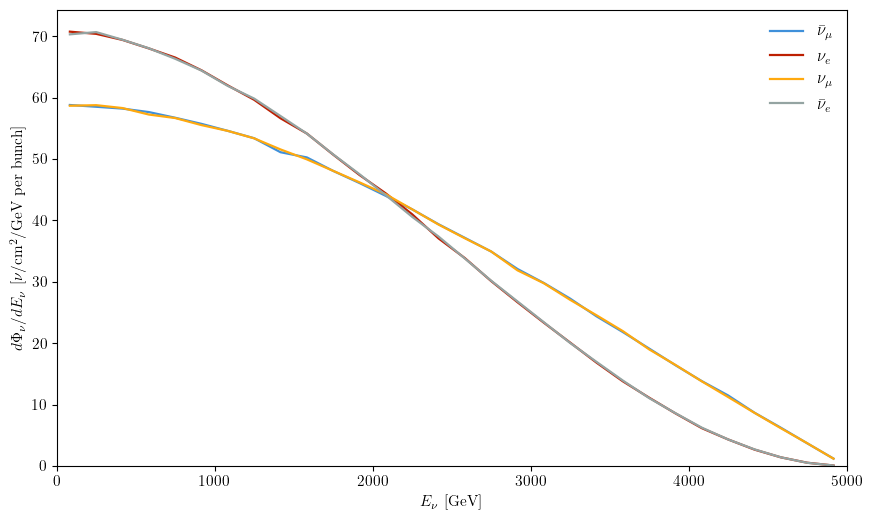

In [16]:

# Results are stored in results["flux"]["ring"] and accessible via get_flux()

# For backwards compatibility, use the pre-computed results:
flux_results = results["flux"]["ring"]

# Plot flux spectrum for main neutrino flavors
fig, ax = pt.std_fig(figsize=(10, 6))
label = {"numubar": r"$\bar\nu_\mu$", "nue": r"$\nu_e$", "numu": r"$\nu_\mu$", "nuebar": r"$\bar\nu_e$"}
for flavor in ["numubar", "nue", "numu", "nuebar"]:
    ax.plot(energy_centers, flux_results[flavor], lw=1.6, label=label[flavor])
    ax.set_xlabel(r"$E_\nu$ [GeV]")

ax.set_xlim(0, 5e3)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$/cm$^{2}$/GeV per bunch]")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_flux_spectrum.pdf", dpi=300, bbox_inches="tight")


In [17]:

dN_dr_per_year_per_m_numubar = results["event_rate_radial"]["ring"]["numubar"]
dN_dr_per_year_per_m_nue = results["event_rate_radial"]["ring"]["nue"]
dN_dr_per_year_per_m_numubar_noBD = results["event_rate_radial"]["ring"]["numubar_nobd"]
dN_dr_per_year_per_m_nue_noBD = results["event_rate_radial"]["ring"]["nue_nobd"]
dN_dr_per_year_per_m_numu = results["event_rate_radial"]["ring"]["numu"]
dN_dr_per_year_per_m_numu_noBD = results["event_rate_radial"]["ring"]["numu_nobd"]

print("✓ Event rates loaded from consolidated results")


✓ Event rates loaded from consolidated results


In [18]:
# Build a new Lattice object from the straight_df
from mint import lattice_tools as lt

straight_dict = bopt.create_smoothed_lattice(
    straight_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)

# Build the new Lattice object
new_lattice = lt.Lattice(**straight_dict)
new_lattice.name = "straightened_lattice"
new_lattice.short_name = "straight"

# Operation assumptions
new_lattice.Nmu_per_bunch = 2e12
new_lattice.finj = 5.0
new_lattice.bunch_multiplicity = 1.0
new_lattice.duty_factor = 1 / np.pi # 1e7 seconds per year


Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x318397bb0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x318396e40>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x318394ff0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x318394eb0>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x318394d20>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x318395810>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x318394cd0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x318395680>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x318395590>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x318395540>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

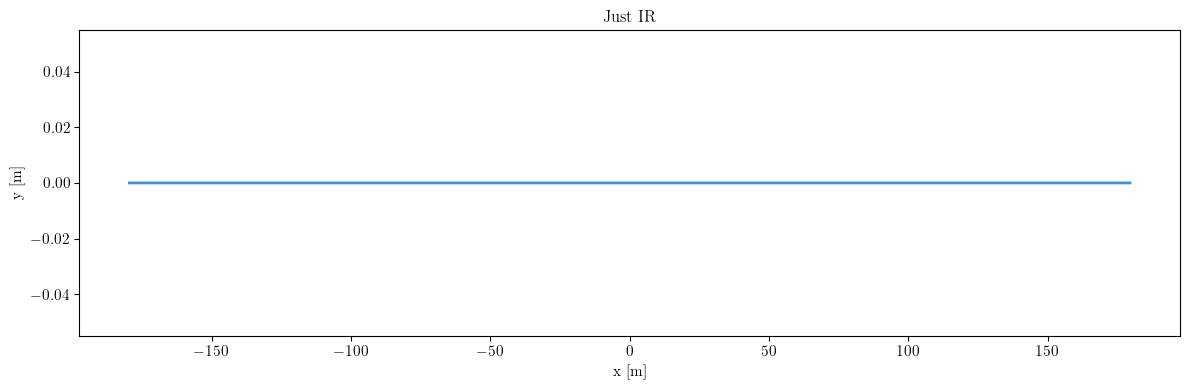

In [19]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(new_lattice.x(u)/100, new_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Just IR")
#ax.set_ylim(-0.1,0.01)
#ax.set_xlim(-200,200)
fig.tight_layout()

In [20]:
# Build a new Lattice object from the straight_df
from mint import lattice_tools as lt

no_chicane = bopt.create_smoothed_lattice(
    curved_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)

# Build the new Lattice object
new_lattice2 = lt.Lattice(**no_chicane)
new_lattice2.name = "no_chicane_lattice"
new_lattice2.short_name = "no_chicane"

# Operation assumptions
new_lattice2.Nmu_per_bunch = 2e12
new_lattice2.finj = 5.0
new_lattice2.bunch_multiplicity = 1.0
new_lattice2.duty_factor = 1 / np.pi # 1e7 seconds per year

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x3182aae40>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x3182aac10>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x3182a9e00>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x3182a9f90>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x3182aa990>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x3182a8e10>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x3182a85f0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x3182aa210>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x3182a8410>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x3182a8280>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

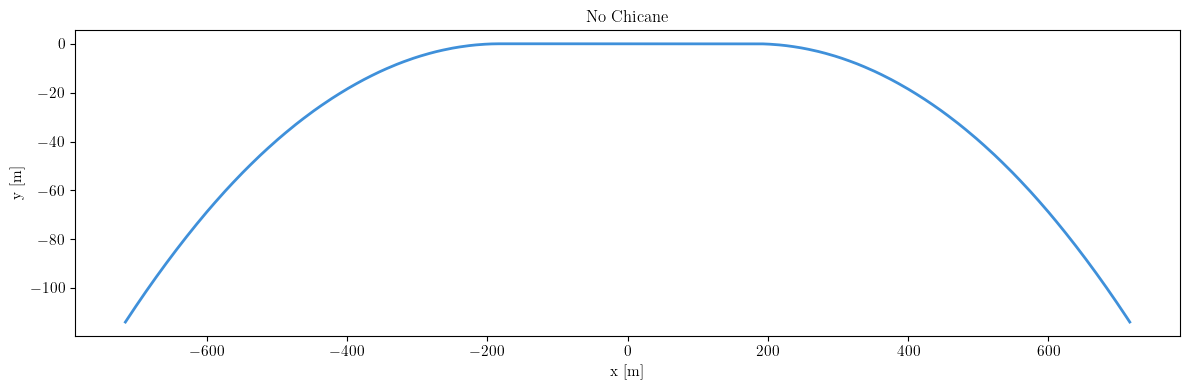

In [21]:
# Quick geometry and reference momentum profile

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(new_lattice2.x(u)/100, new_lattice2.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("No Chicane")
#ax.set_ylim(-0.1,0.01)
#ax.set_xlim(-200,200)
fig.tight_layout()

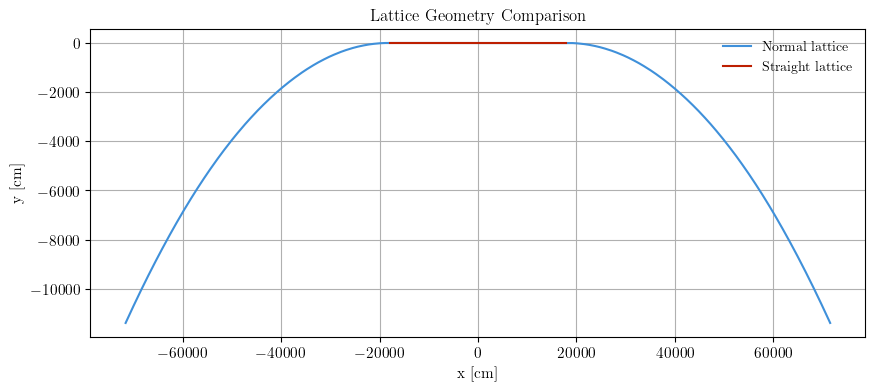

In [22]:
# Compare the geometry of the normal and straight lattices
import matplotlib.pyplot as plt
u = np.linspace(0, 1, 1000)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ring_lattice.x(u), ring_lattice.y(u), label="Normal lattice")
ax.plot(new_lattice.x(u), new_lattice.y(u), label="Straight lattice")
# Mark detector location (projected onto x-y plane)

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Lattice Geometry Comparison")
ax.legend()
ax.grid(True)
plt.show()

In [23]:

dN_dr_per_year_per_m_numubar_straight = results["event_rate_radial"]["straight"]["numubar"]
dN_dr_per_year_per_m_numubar_noBD_straight = results["event_rate_radial"]["straight"]["numubar_nobd"]

print("✓ Straight lattice event rates loaded")

dN_dr_per_year_per_m_numubar_no_chicane = results["event_rate_radial"]["no_chicane"]["numubar"]
dN_dr_per_year_per_m_numubar_noBD_no_chicane = results["event_rate_radial"]["no_chicane"]["numubar_nobd"]

print("✓ No-chicane lattice event rates loaded")


✓ Straight lattice event rates loaded
✓ No-chicane lattice event rates loaded


In [24]:
def calculate_event_weight_uncertainty_radial(sim, flavor, r_edges, det_location):
    """
    Event-based binning: for each event, compute its radial distance to the detector axis, bin its weight into the appropriate annulus, and apply the probability of interaction at the detector.
    Returns: event rate per annulus (events per year per m)
    """
    import numpy as np
    # Get event positions and directions
    det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    # Only consider events that are forward-going and within energy range
    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    # Bin by radial distance
    r_edges = np.asarray(r_edges)
    weights = sim.weights.flatten()
    # Only use accepted events
    r_accepted = radial_distance[in_acceptance]
    w_accepted = weights[in_acceptance]
    E_accepted = sim.pnu["E"][in_acceptance]

    # Calculate interaction probability for each event
    sigma = xsecs.total_xsecs[flavor](E_accepted)  # shape: (n_events,)
    p_int = sigma * nucleon_column_density  # probability of interaction per event
    event_weights = w_accepted * p_int * bunches_per_year
    

    # Bin event weights by radial distance
    sum_weights_sq, _ = np.histogram(r_accepted, bins=r_edges, weights=event_weights**2)
    uncertainty = np.sqrt(sum_weights_sq)

    dr = np.diff(r_edges)  # cm
    # Convert to per meter (multiply by 100)
    uncertainty_per_cm = uncertainty / dr
    uncertainty_per_m = uncertainty_per_cm * 100.0
    
    return uncertainty_per_m


Max signal: 2.21e+10
Max uncertainty/dr: 2.20e+07
Relative uncertainty: 2.61%


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/964841407.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


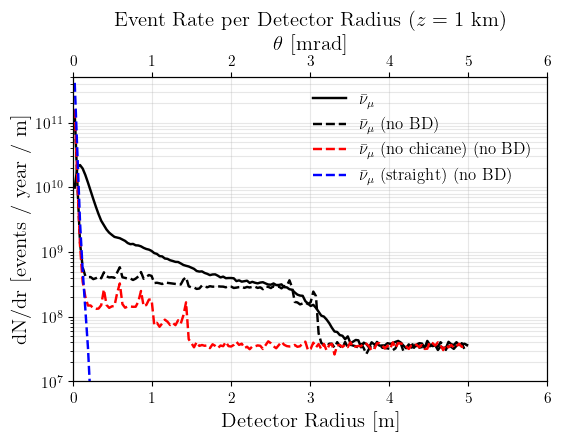

In [25]:

# plot
fig, ax = pt.std_fig(figsize=(6, 4))


# r_edges = np.linspace(0.0, 10e2, 150)
r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar, lw=1.75, label=label["numubar"], color='black')
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_no_chicane, lw=1.6, label=label["numubar"]+" (no chicane)")
# ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_straight, lw=1.6, label=label["numubar"]+" (straight)")

plt.gca().set_prop_cycle(None)

dr = np.diff(r_edges)  # Convert to dN/dr uncertainty

numubar_uncertainty = calculate_event_weight_uncertainty_radial(sims["ring"]["numubar"], "numubar", r_edges, det_location)
numubar_uncertainty_no_chicane = calculate_event_weight_uncertainty_radial(sims["no_chicane"]["numubar"], "numubar", r_edges, det_location)
numubar_uncertainty_straight = calculate_event_weight_uncertainty_radial(sims["straight"]["numubar"], "numubar", r_edges, det_location)

# ax.fill_between(r_centers/100.0, dN_dr_per_year_per_m_numubar-(numubar_uncertainty), dN_dr_per_year_per_m_numubar+(numubar_uncertainty), alpha=0.3)
# ax.fill_between(r_centers/100.0, dN_dr_per_year_per_m_numubar_no_chicane-(numubar_uncertainty_no_chicane), dN_dr_per_year_per_m_numubar_no_chicane+(numubar_uncertainty_no_chicane), alpha=0.3)
# ax.fill_between(r_centers/100.0, dN_dr_per_year_per_m_numubar_straight-(numubar_uncertainty_straight), dN_dr_per_year_per_m_numubar_straight+(numubar_uncertainty_straight), alpha=0.3)

ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD, lw=1.75, ls='--', label=label["numubar"]+r' (no BD)', color='black')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD_no_chicane, lw=1.75, ls='--', label=label["numubar"]+" (no chicane)"+r' (no BD)', color='red')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD_straight, lw=1.75, ls='--', label=label["numubar"]+" (straight)"+r' (no BD)', color='blue')

print(f"Max signal: {dN_dr_per_year_per_m_numubar.max():.2e}")
print(f"Max uncertainty/dr: {(numubar_uncertainty/dr).max():.2e}")
print(f"Relative uncertainty: {((numubar_uncertainty/dr) / dN_dr_per_year_per_m_numubar).max():.2%}")

ax2 = ax.twiny()
ax2.set_xlim(0, 6)  # Match the main axis limits
ax2.set_xlabel("$\\theta$ [mrad]", fontsize=15)

ax.set_xlabel("Detector Radius [m]", fontsize=15)
ax.set_ylabel("dN/dr [events / year / m]", fontsize=15)
ax.set_xlim(0, 6)
# ax.set_xscale
ax.grid(True, which='both', ls='-', alpha=0.3)
ax.set_ylim(1e7, 5e11)
ax.set_yscale('log')
# ax.set_xscale('log')
ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Event Rate per Detector Radius ($z = 1$ km)", fontsize=15)
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial(6m).pdf", dpi=300, bbox_inches="tight")

/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/965334377.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


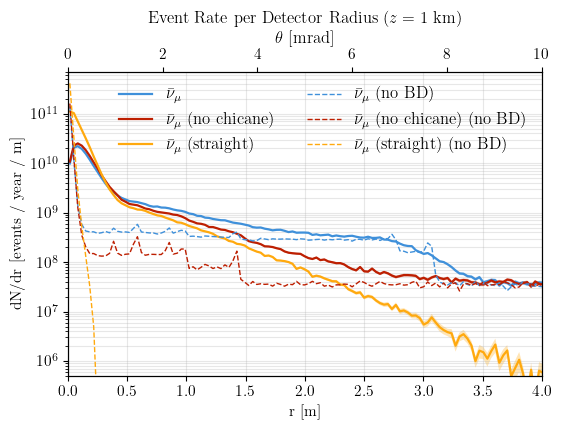

In [26]:
# plot
fig, ax = pt.std_fig(figsize=(6, 4))

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar, lw=1.6, label=label["numubar"])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_no_chicane, lw=1.6, label=label["numubar"]+" (no chicane)")
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_straight, lw=1.6, label=label["numubar"]+" (straight)")

plt.gca().set_prop_cycle(None)

dr = np.diff(r_edges)  # Convert to dN/dr uncertainty

numubar_uncertainty = calculate_event_weight_uncertainty_radial(sims["ring"]["numubar"], "numubar", r_edges, det_location)
numubar_uncertainty_no_chicane = calculate_event_weight_uncertainty_radial(sims["no_chicane"]["numubar"], "numubar", r_edges, det_location)
numubar_uncertainty_straight = calculate_event_weight_uncertainty_radial(sims["straight"]["numubar"], "numubar", r_edges, det_location)

ax.fill_between(r_centers/100.0, dN_dr_per_year_per_m_numubar-(numubar_uncertainty), dN_dr_per_year_per_m_numubar+(numubar_uncertainty), alpha=0.3)
ax.fill_between(r_centers/100.0, dN_dr_per_year_per_m_numubar_no_chicane-(numubar_uncertainty_no_chicane), dN_dr_per_year_per_m_numubar_no_chicane+(numubar_uncertainty_no_chicane), alpha=0.3)
ax.fill_between(r_centers/100.0, dN_dr_per_year_per_m_numubar_straight-(numubar_uncertainty_straight), dN_dr_per_year_per_m_numubar_straight+(numubar_uncertainty_straight), alpha=0.3)


ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD, lw=1., ls='--', label=label["numubar"]+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD_no_chicane, lw=1., ls='--', label=label["numubar"]+" (no chicane)"+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numubar_noBD_straight, lw=1., ls='--', label=label["numubar"]+" (straight)"+r' (no BD)')

ax2 = ax.twiny()
ax2.set_xlim(0, 10)  # Match the main axis limits
ax2.set_xlabel("$\\theta$ [mrad]", fontsize=12)

ax.set_xlabel("r [m]")
ax.set_ylabel("dN/dr [events / year / m]")
ax.set_xlim(0, 4)
# ax.set_xscale
ax.grid(True, which='both', ls='-', alpha=0.3)
ax.set_ylim(5e5, 7e11)
ax.set_yscale('log')
ax.legend(frameon=False, fontsize=12, ncol=2)
ax.set_title(r"Event Rate per Detector Radius ($z = 1$ km)")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial(4m).pdf", dpi=300, bbox_inches="tight")

## Estimate forward event rate

In [27]:
def calculate_event_weight_uncertainty(sim, flavor, energy_edges, det_location):
    """
    Calculate sqrt(sum(w_i^2)) for each energy bin to estimate MC uncertainty.
    """
    det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    
    dotprod = distances.dot(neutrino_direction)

    z_det = det_location[2]
    t = (z_det - sim.pos["z"]) / sim.pnu["pz"]
    x_hit = sim.pos["x"] + t * sim.pnu["px"]
    y_hit = sim.pos["y"] + t * sim.pnu["py"]
    
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0) & (np.sqrt(x_hit**2 + y_hit**2) < det_radius)
    
    E_accepted = sim.pnu["E"][in_acceptance]
    w_accepted = sim.weights[in_acceptance].flatten()
    
    sigma = xsecs.total_xsecs[flavor](E_accepted)
    p_int = sigma * nucleon_column_density
    event_weights = w_accepted * p_int * bunches_per_year
    
    # Bin event weights by energy
    sum_weights_sq, _ = np.histogram(E_accepted, bins=energy_edges, weights=event_weights**2)
    uncertainty = np.sqrt(sum_weights_sq)
    
    return uncertainty

MC uncertainty for numubar (detector at 1 km): [  54828.66622184  152907.2321773   256771.47027622  361514.06011435
  467801.57436987  573980.45907221  679782.31858178  781117.00578946
  873324.88017975  984667.23623628 1075157.5200716  1172313.70918267
 1254606.11030894 1338619.08101671 1408517.7175827  1487340.71180744
 1557400.59870942 1606078.06481893 1664154.05510398 1709814.79475342
 1733419.32382055 1756333.02156159 1761739.76721565 1732089.55126046
 1705365.0856105  1670273.62553655 1552693.68199408 1409319.24572873
 1154855.3936574   610813.70327635]
MC uncertainty for nue (detector at 1 km): [ 126494.59697741  337418.90707416  549095.21387568  759384.74070103
  968625.52932362 1175823.34756657 1366739.62889223 1557289.73881669
 1730853.96385455 1914971.76157796 2075175.41962691 2222802.60507499
 2359653.80686191 2461915.01204703 2520857.00527857 2584098.26827216
 2599806.99300668 2591483.08858724 2533343.44510179 2362283.29093325
 2041239.73576599 1741257.82515024 1497078.450

/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/1817774131.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


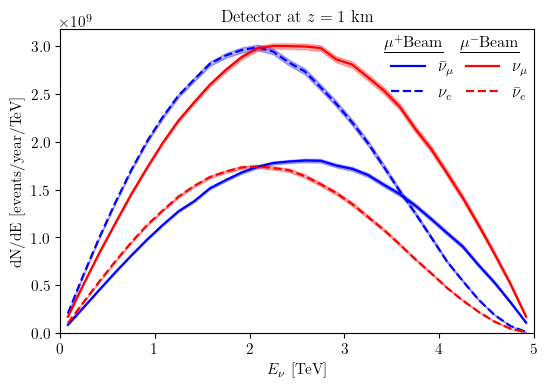

In [28]:
GeV_to_TeV = 1e-3
event_results = {}
energy_edges = np.linspace(0, 5e3, 31)
for flavor in ["numubar", "nue", "numu", "nuebar"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }


for flavor in ["numubar", "nue", "numu", "nuebar"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor+'_nobd'] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor+'_nobd'] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

fig, ax = pt.std_fig(figsize=(6, 4))

colors = {"numubar": "blue", "nue": "blue", "numu": "red", "nuebar": "red"}
ls = {"numubar": "-", "nue": "--", "numu": "-", "nuebar": "--"}

mc_uncertainties = {"numubar":0, "nue":0, "numu":0, "nuebar":0}
for flavor in ["numubar", "nue", "numu", "nuebar"]:
    if flavor == "numu" or flavor == "nuebar":
        mc_uncertainties[flavor] = calculate_event_weight_uncertainty(sims["ring"][flavor], flavor, energy_edges, det_location_upstream)
        print(f"MC uncertainty for {flavor} (detector at -1 km): {mc_uncertainties[flavor]}")
    else:
        mc_uncertainties[flavor] = calculate_event_weight_uncertainty(sims["ring"][flavor], flavor, energy_edges, det_location)
        print(f"MC uncertainty for {flavor} (detector at 1 km): {mc_uncertainties[flavor]}")

dE = np.diff(energy_edges)  # Convert to dN/dE uncertainty

for flavor in ["numubar", "nue", "numu", "nuebar"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor]["dN_dE_per_year"]/GeV_to_TeV,lw=1.6, label=label[flavor], color=colors[flavor], ls=ls[flavor])
    ax.fill_between(energy_centers*GeV_to_TeV, (event_results[flavor]["dN_dE_per_year"] - (2*mc_uncertainties[flavor]/dE))/(GeV_to_TeV), (event_results[flavor]["dN_dE_per_year"] + (2*mc_uncertainties[flavor]/dE))/(GeV_to_TeV), color=colors[flavor], alpha=0.3)

plt.gca().set_prop_cycle(None)

ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"dN/dE [events/year/TeV]")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)

ax.text(0.745, 0.982, r"$\underline{\mu^+ \text{Beam}}$", transform=ax.transAxes, 
        fontsize=11.5, ha='center', va='top')

ax.text(0.907, 0.982, r"$\underline{\mu^- \text{Beam}}$", transform=ax.transAxes, 
        fontsize=11.5, ha='center', va='top')

ax.legend(frameon=False, fontsize=12, ncol=2, loc=(0.685, 0.745),columnspacing=0.75)
ax.set_title(r"Detector at $z = 1$ km", fontsize=12)
fig.tight_layout()

tot_numu = np.trapezoid(event_results["numubar"]["dN_dE_per_year"], energy_centers)
tot_nue = np.trapezoid(event_results["nue"]["dN_dE_per_year"], energy_centers)
tot_numu = np.trapezoid(event_results["numu"]["dN_dE_per_year"], energy_centers)
tot_nuebar = np.trapezoid(event_results["nuebar"]["dN_dE_per_year"], energy_centers)

print(f"Estimated total forward event rate (numubar): {tot_numu:.3e} events/year")
print(f"Estimated total forward event rate (nue):  {tot_nue:.3e} events/year")
print(f"Estimated total forward event rate (numu):  {tot_numu:.3e} events/year")
print(f"Estimated total forward event rate (nuebar): {tot_nuebar:.3e} events/year")


fig.savefig("plots/hybrid_v06_event_rate_spectrum.pdf", dpi=300, bbox_inches="tight")

## 2D Histogram of Energy vs. Detector radius

In [29]:
def E_vs_radius_event_map(sim, flavor, det_location=det_location, ebins=energy_edges, r_edges=r_edges, norm=False):
    det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    # Compute per-event cross-sections and interaction probabilities
    E_accepted = sim.pnu["E"][in_acceptance]
    sigma = xsecs.total_xsecs[flavor](E_accepted)  # Shape: (n_events,)
    p_int = sigma * nucleon_column_density  # Shape: (n_events,)

    # Compute event weights (per event)
    w_accepted = sim.weights[in_acceptance].flatten()
    event_weights = w_accepted * p_int * bunches_per_year # Shape: (n_events,)

    # Extract accepted radii and energies
    r_accepted = radial_distance[in_acceptance]

    print(np.sum(event_weights))

    if norm:
    # Compute 2D histogram using per-event data
        hist, xedges, yedges = np.histogram2d(r_accepted, E_accepted, bins=[r_edges, ebins], weights=event_weights, density=True)
    else:   # Compute 2D histogram using per-event data
        hist, xedges, yedges = np.histogram2d(r_accepted, E_accepted, bins=[r_edges, ebins], weights=event_weights)
    # Sum along axis 1 (rows) and keep dimensions for broadcasting
    # row_sums = hist.sum(axis=1, keepdims=True)

    # # Avoid division by zero for empty bins
    # hist_normalized = np.divide(hist, row_sums, out=np.zeros_like(hist), where=row_sums!=0)
    
    return hist, xedges, yedges

24016301276.20841


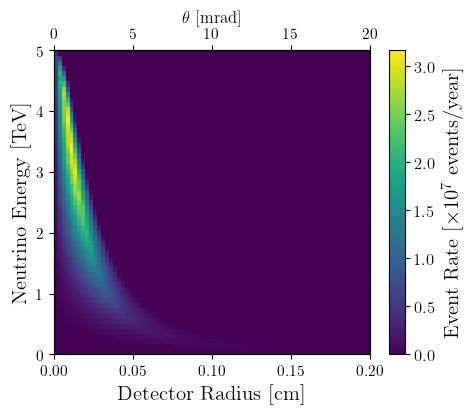

In [42]:
energy_edges = np.linspace(0, 5e3, 60)
r_edges1 = np.linspace(0.0, det_radius, 200)
hist, xedges, yedges = E_vs_radius_event_map(sims["ring"]["numubar_nobd"], "numubar", det_location=det_location, ebins=energy_edges, r_edges=r_edges1)

fig, ax = pt.std_fig(figsize=(5, 4))

ax2 = ax.twiny()
ax2.set_xlim(0, r_edges1[-1])  # Match the main axis limits
ax2.set_xlabel("$\\theta$ [mrad]", fontsize=12)

# Plot

im = ax.pcolormesh(xedges/100, yedges/1000,hist.T/10**7, cmap='viridis')
ax.set_xlabel('Detector Radius [cm]',fontsize=15)
ax.set_ylabel('Neutrino Energy [TeV]',fontsize=15)
cb=fig.colorbar(im, ax=ax, label='Event Rate [$\\times 10^7$ events/year]')

cb.ax.tick_params(labelsize=12)

cb.set_label("Event Rate [$\\times 10^7$ events/year]", size=15)

# ax.text(0.785, 0.95, r"z = 1km", transform=ax.transAxes, 
#         fontsize=15, fontweight='bold', ha='center', va='top',color='white')
# ax.text(0.785, 0.85, r"l = 10m", transform=ax.transAxes, 
#         fontsize=15, fontweight='bold', ha='center', va='top',color='white')
# ax.text(0.785, 0.75, r"$\rho$ = 1 g/cm$^3$", transform=ax.transAxes, 
#         fontsize=15, fontweight='bold', ha='center', va='top',color='white')
# ax.text(0.685, 0.55, r"$\underline{\text{no Beam Dyanmics}}$", transform=ax.transAxes, 
#         fontsize=15, fontweight='bold', ha='center', va='top',color='white')



detector_length_cm = 10e2  # 10 m target depth
rho_g_cm3 = 1.00

ax.set_xlim(0, .2)
ax2.set_xlim(0, 20)  # Match the main axis limits
# plt.tight_layout()
plt.show()

fig.savefig("plots/Neutrino_Energy_vs_Radius(noBD).pdf", dpi=300, bbox_inches="tight")

24015972333.58798


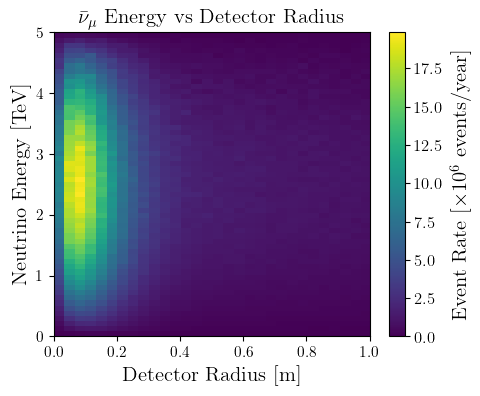

In [31]:

energy_edges = np.linspace(0, 5e3, 60)
# r_edges = np.linspace(0.0, 30, 60)
hist, xedges, yedges = E_vs_radius_event_map(sims["ring"]["numubar"], "numubar", det_location=det_location, ebins=energy_edges, r_edges=r_edges)

fig, ax = pt.std_fig(figsize=(5,4))

ax.set_xlim(0,100)

# ax2 = ax.twiny()
# ax2.set_xlim(0, r_edges[-1]/1e2)  # Match the main axis limits
# ax2.set_xlabel("$\\theta$ [mrad]", fontsize=12)

# Plot

# ax.text(0.35, 0.08, r"$\underline{\text{with Beam Dyanmics}}$", transform=ax.transAxes, 
#         fontsize=15, fontweight='bold', ha='center', va='top',color='white')

im = ax.pcolormesh(xedges/100, yedges/1000,hist.T/10**6, cmap='viridis')
ax.set_xlabel('Detector Radius [m]',fontsize=15)
ax.set_ylabel('Neutrino Energy [TeV]',fontsize=15)
cb = fig.colorbar(im, ax=ax)
cb.ax.tick_params(labelsize=12)
cb.set_label("Event Rate [$\\times 10^6$ events/year]", size=15)
ax.set_title(r'$\bar{\nu}_\mu$ Energy vs Detector Radius', fontsize=15)
ax.set_xlim(0, 1)
#plt.xlim(0, 20)
# plt.tight_layout()
plt.show()

fig.savefig("plots/Neutrino_Energy_vs_Radius.pdf", dpi=300, bbox_inches="tight")

24015972333.58798


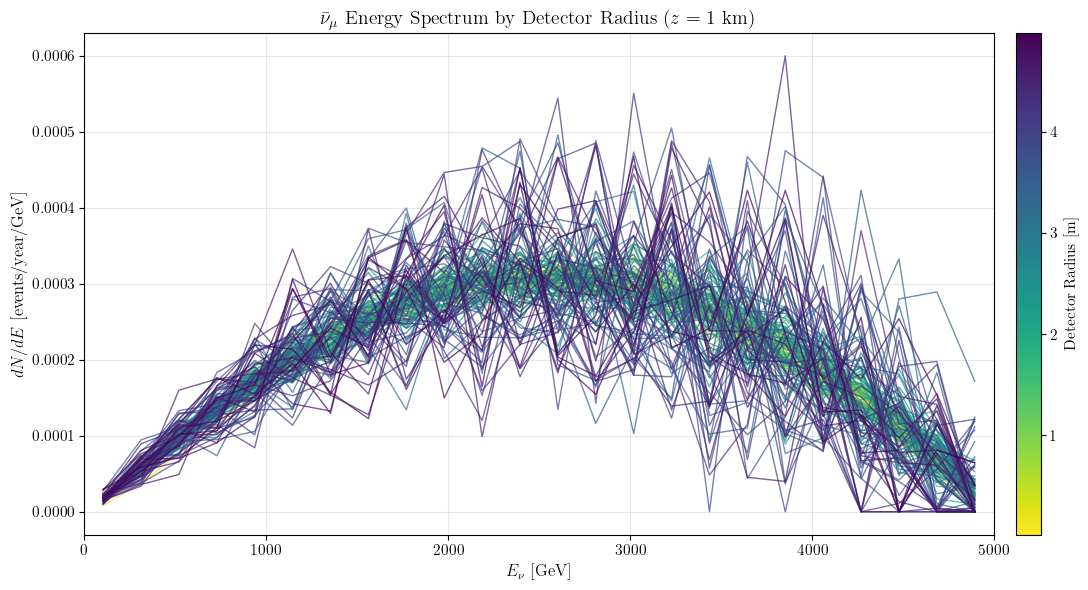

In [32]:
# Plot dN/dE vs Energy for each radial bin with different colors
e_edges = np.linspace(0, 5e3, 25)  # 51 energy bins in GeV

# Get the 2D histogram
hist, r_bin_edges, e_bin_edges = E_vs_radius_event_map(
    sims["ring"]["numubar"], "numubar", 
    det_location=det_location, 
    ebins=e_edges, 
    r_edges=r_edges,
)

# Compute energy centers and radial centers
r_centers = 0.5 * (r_bin_edges[:-1] + r_bin_edges[1:])
e_centers = 0.5 * (e_bin_edges[:-1] + e_bin_edges[1:])

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Normalize radii for colormap
n_radii = len(r_centers)
cmap = plt.cm.viridis_r
colors = cmap(np.linspace(0, 1, n_radii))

# Plot dN/dE for each radial bin
for i in range(n_radii):
    if hist[i, :].sum() > 0:  # Only plot if bin has events
        dE = np.diff(e_bin_edges)
        dN_dE = hist[i, :] / dE / np.sum(hist[i, :])  # Normalize to get dN/dE
        ax.plot(e_centers, dN_dE, color=colors[i], lw=1.0, alpha=0.7)

ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=12)
ax.set_ylabel(r"$dN/dE$ [events/year/GeV]", fontsize=12)
ax.set_xlim(0, 5e3)
# ax.set_yscale('log')
# ax.set_ylim(10, None)
ax.grid(True, which='both', ls='-', alpha=0.3)
ax.set_title(r"$\bar\nu_\mu$ Energy Spectrum by Detector Radius ($z = 1$ km)", fontsize=14)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=r_centers.min()/100, vmax=r_centers.max()/100))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Detector Radius [m]", pad=0.02)

fig.tight_layout()
fig.savefig("plots/energy_spectrum_by_radius.pdf", dpi=300, bbox_inches="tight")
plt.show()

24016301276.20841


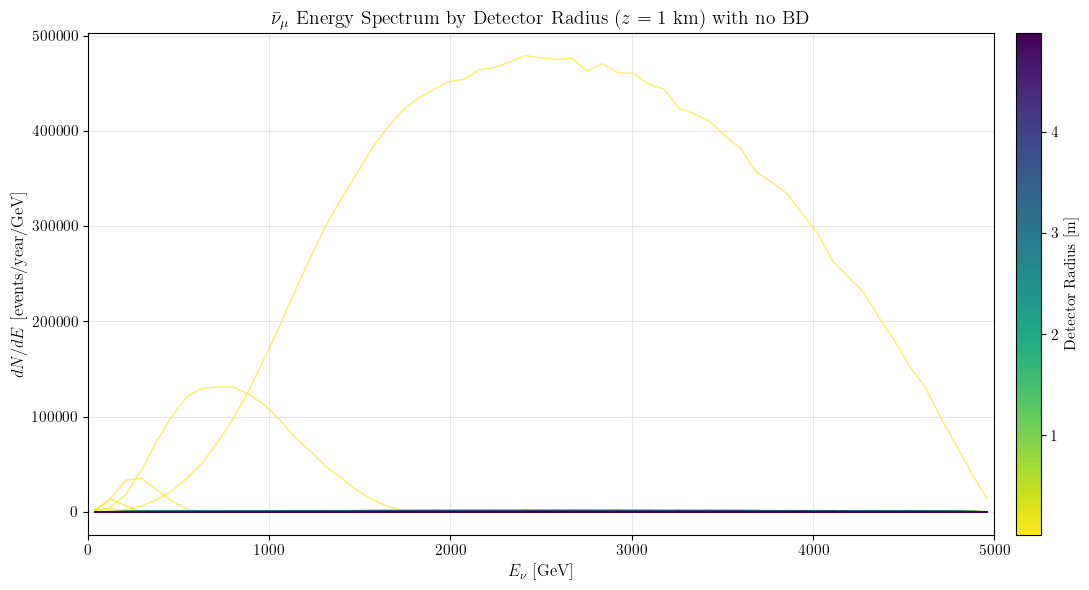

In [33]:
# Plot dN/dE vs Energy for each radial bin with different colors
e_edges = np.linspace(0, 5e3, 60)  # 51 energy bins in GeV

# Get the 2D histogram
hist, r_bin_edges, e_bin_edges = E_vs_radius_event_map(
    sims["ring"]["numubar_nobd"], "numubar", 
    det_location=det_location, 
    ebins=e_edges, 
    r_edges=r_edges,
)

# Compute energy centers and radial centers
r_centers = 0.5 * (r_bin_edges[:-1] + r_bin_edges[1:])
e_centers = 0.5 * (e_bin_edges[:-1] + e_bin_edges[1:])

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Normalize radii for colormap
n_radii = len(r_centers)
cmap = plt.cm.viridis_r
colors = cmap(np.linspace(0, 1, n_radii))

# Plot dN/dE for each radial bin
for i in range(n_radii):
    dE = np.diff(e_bin_edges)
    dr = np.diff(r_bin_edges)
    dN_dE = hist[i, :] / dE / dr[i]  # Normalize to get dN/dE shape
    ax.plot(e_centers, dN_dE, color=colors[i], lw=1.0, alpha=0.7)    

# Plot total events vs Energy (sum across all radii)
total_events_per_energy = np.sum(hist, axis=0)  # Sum over radial bins

#ax.plot(e_centers, total_events_per_energy/dE /dr[i], lw=2.0, alpha=0.7)

ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=12)
ax.set_ylabel(r"$dN/dE$ [events/year/GeV]", fontsize=12)
ax.set_xlim(0, 5e3)
# ax.set_yscale('log')
# ax.set_ylim(10, None)
ax.grid(True, which='both', ls='-', alpha=0.3)
ax.set_title(r"$\bar\nu_\mu$ Energy Spectrum by Detector Radius ($z = 1$ km) with no BD", fontsize=14)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=r_centers.min()/100, vmax=r_centers.max()/100))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Detector Radius [m]", pad=0.02)

fig.tight_layout()
fig.savefig("plots/energy_spectrum_by_radius_nobd.pdf", dpi=300, bbox_inches="tight")
plt.show()

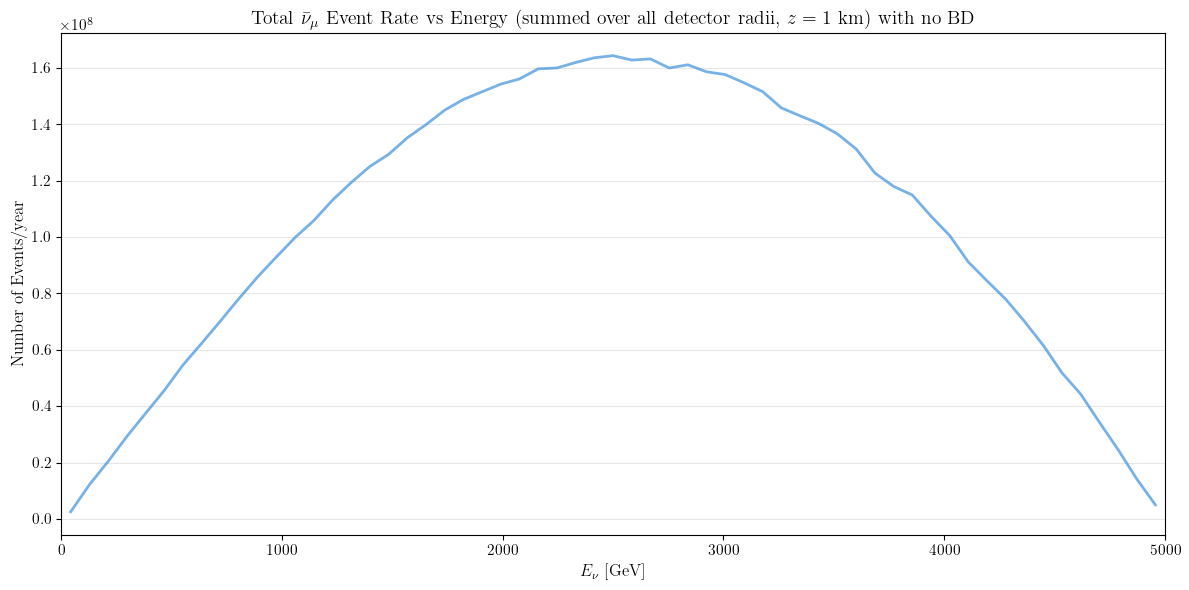

In [34]:
# Plot total events vs Energy (sum across all radii)
total_events_per_energy = np.sum(hist, axis=0)  # Sum over radial bins

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(e_centers, total_events_per_energy, lw=2.0, alpha=0.7)

ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=12)
ax.set_ylabel(r"Number of Events/year", fontsize=12)
ax.set_xlim(0, 5e3)
ax.grid(True, which='both', ls='-', alpha=0.3, axis='y')
ax.set_title(r"Total $\bar\nu_\mu$ Event Rate vs Energy (summed over all detector radii, $z = 1$ km) with no BD", fontsize=14)

fig.tight_layout()
fig.savefig("plots/total_events_vs_energy_nobd.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Transverse 2D Event Rate Plot

/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/2716164654.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


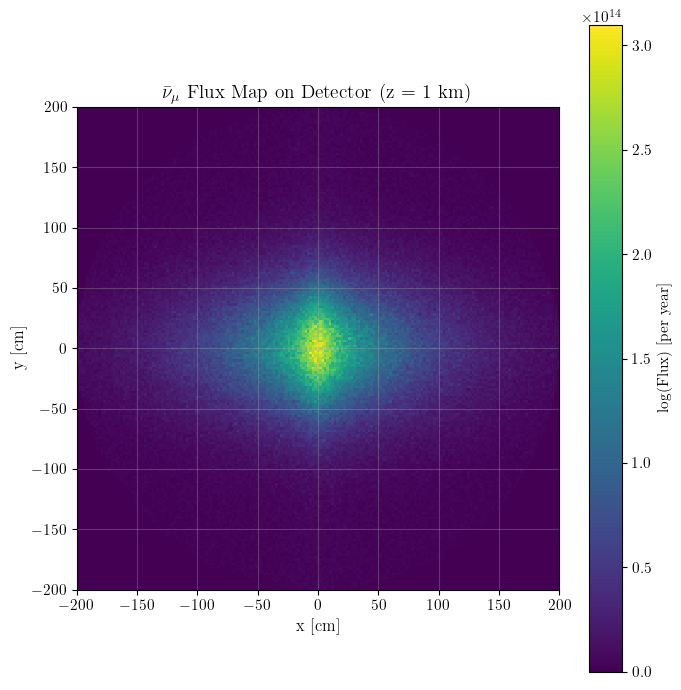

In [44]:
from matplotlib.colors import LogNorm

# 2D Detector Map: Neutrino Hit Positions Colored by Flux

det_radius = 2e2  # cm

# Select a flavor to visualize
flavor_to_plot = "numubar"
sim = sims["ring"][flavor_to_plot]

# Extract position data for events in acceptance
det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
distances = det_vector - sim.pos
neutrino_direction = sim.pnu.to_3D().unit()

dotprod = distances.dot(neutrino_direction)

z_det = 5e5
t = (z_det - sim.pos["z"]) / sim.pnu["pz"]
x_hit = sim.pos["x"] + t * sim.pnu["px"]
y_hit = sim.pos["y"] + t * sim.pnu["py"]

in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0) & (np.sqrt(x_hit**2 + y_hit**2) < det_radius)
# in_acceptance = np.ones_like(dotprod, dtype=bool)

x_hit = x_hit[in_acceptance]
y_hit = y_hit[in_acceptance]
w_accepted = sim.weights[in_acceptance].flatten() 


flux_weights = w_accepted * bunches_per_year

# Create 2D histogram
x_bins = np.linspace(-det_radius, det_radius,200)
y_bins = np.linspace(-det_radius, det_radius, 200)

hist_2d, xedges, yedges = np.histogram2d(x_hit, y_hit, bins=[x_bins, y_bins], weights=flux_weights)


# Plot
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.pcolormesh(xedges, yedges, (hist_2d), shading='auto', cmap='viridis')
# im = ax.pcolormesh(xedges, yedges, hist_2d, shading='auto', cmap='viridis',norm=LogNorm(vmin=hist_2d[hist_2d > 0].min(), vmax=hist_2d.max()))
cbar = plt.colorbar(im, ax=ax, label='log(Flux) [per year]')

# Draw detector circle
# circle = plt.Circle((0, 0), det_radius, fill=False, edgecolor='red', linestyle='--', linewidth=2, label='Detector Boundary')
# ax.add_patch(circle)

ax.set_title(r'$\bar\nu_\mu$ Flux Map on Detector (z = 1 km)', fontsize=14)
ax.set_xlim(-det_radius, det_radius)
ax.set_ylim(-det_radius, det_radius)
ax.set_xlabel('x [cm]', fontsize=12)
ax.set_ylabel('y [cm]', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig("plots/detector_flux_map_2d.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# Create a copy of the main collider-ring lattice with symmetric y-plane optics
ring_dict_sym = dict(ring_dict)
ring_dict_sym["beamsize_y"] = ring_dict_sym["beamsize_x"]
ring_dict_sym["beamdiv_y"] = ring_dict_sym["beamdiv_x"]
if "betx" in ring_dict_sym:
    ring_dict_sym["bety"] = ring_dict_sym["betx"]

ring_lattice_sym = lt.Lattice(**ring_dict_sym)
ring_lattice_sym.name = f"{ring_lattice.name}_sym"
ring_lattice_sym.short_name = f"{ring_lattice.short_name}_sym"
ring_lattice_sym.Nmu_per_bunch = ring_lattice.Nmu_per_bunch
ring_lattice_sym.duty_factor = ring_lattice.duty_factor
ring_lattice_sym.bunch_multiplicity = ring_lattice.bunch_multiplicity
ring_lattice_sym.finj = ring_lattice.finj

sim_sym = MuDecaySimulator(
            cycles=1e3,
            muon_polarization=0.0,
            nuflavor="numubar", 
            direction="clockwise",
            n_evals=n_evals,
            beam_dynamics=True
        )
sim_sym.decay_muons()

sim_sym.place_muons_on_lattice(lattice=ring_lattice_sym, direction="clockwise")


Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae2b0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae300>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae3a0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x1773ae3a0>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae440>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x1773ae490>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x1773ae4e0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x1773ae530>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x1773ae580>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x1773ae5d0>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/4005038975.py:34: RuntimeWarning: divide by zero encountered in log10
  im = ax.pcolormesh(xedges, yedges, np.log10(hist_2d), shading='auto', cmap='viridis')
/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_21806/4005038975.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


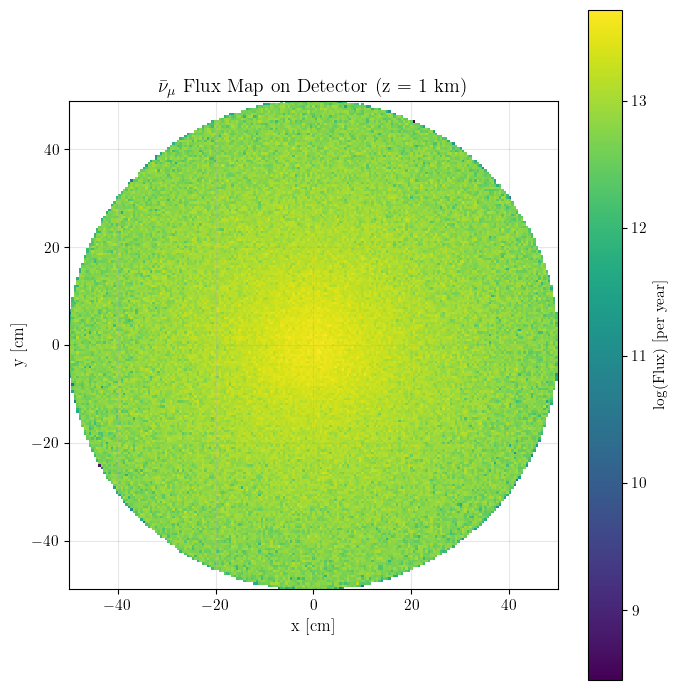

In [37]:
det_radius = 50.0  # cm

# Extract position data for events in acceptance
det_vector = vector.array({"x": det_location[0], "y": det_location[1], "z": det_location[2]})
distances = det_vector - sim_sym.pos
neutrino_direction = sim_sym.pnu.to_3D().unit()

dotprod = distances.dot(neutrino_direction)

z_det = 5e5
t = (z_det - sim_sym.pos["z"]) / sim_sym.pnu["pz"]
x_hit = sim_sym.pos["x"] + t * sim_sym.pnu["px"]
y_hit = sim_sym.pos["y"] + t * sim_sym.pnu["py"]

in_acceptance = (dotprod > 0) & (sim_sym.pnu["E"] > 0) & (np.sqrt(x_hit**2 + y_hit**2) < det_radius)
# in_acceptance = np.ones_like(dotprod, dtype=bool)

x_hit = x_hit[in_acceptance]
y_hit = y_hit[in_acceptance]
w_accepted = sim_sym.weights[in_acceptance].flatten() 


flux_weights = w_accepted * bunches_per_year

# Create 2D histogram
x_bins = np.linspace(-det_radius, det_radius,200)
y_bins = np.linspace(-det_radius, det_radius, 200)

hist_2d, xedges, yedges = np.histogram2d(x_hit, y_hit, bins=[x_bins, y_bins], weights=flux_weights)


# Plot
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.pcolormesh(xedges, yedges, np.log10(hist_2d), shading='auto', cmap='viridis')
# im = ax.pcolormesh(xedges, yedges, hist_2d, shading='auto', cmap='viridis',norm=LogNorm(vmin=hist_2d[hist_2d > 0].min(), vmax=hist_2d.max()))
cbar = plt.colorbar(im, ax=ax, label='log(Flux) [per year]')


ax.set_title(r'$\bar\nu_\mu$ Flux Map on Detector (z = 1 km)', fontsize=14)
ax.set_xlim(-det_radius, det_radius)
ax.set_ylim(-det_radius, det_radius)
ax.set_xlabel('x [cm]', fontsize=12)
ax.set_ylabel('y [cm]', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## Compare Event Rates with Previous Neutrino Experiments

In [38]:
# pull data of neutrino experiments
import os
import csv
nu_spectrum_dir = "nu_spectrum_data"
nu_spectrum_arrays = {}
for fname in os.listdir(nu_spectrum_dir):
    if fname.endswith(".csv") and fname not in {"PA.csv", "RLA1.csv", "RLA2.csv"}:
        arr = []
        with open(os.path.join(nu_spectrum_dir, fname), "r") as f:
            reader = csv.reader(f)
            for row in reader:
                if len(row) >= 2:
                    try:
                        x = float(row[0])
                        y = float(row[1])
                        arr.append((x, y))
                    except ValueError:
                        continue
        key = fname.replace(".csv", "").replace("_", " ")
        nu_spectrum_arrays[key] = arr
# Example: chorus = nu_spectrum_arrays["chorus"]
for key, arr in nu_spectrum_arrays.items():
    globals()[key] = arr

In [39]:
nu_spectrum_arrays.keys()

dict_keys(['NOMAD', 'MuC 10TeV', 'CDHS', 'FPF', 'NuTeV', 'DUNE ND', 'CHORUS', 'FASER'])

## MuC comparison 

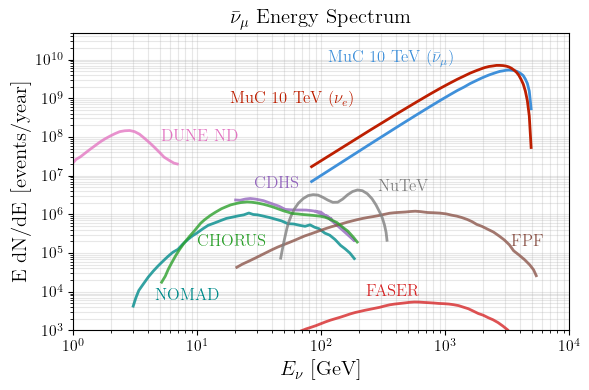

In [40]:
# fig, ax = pt.std_fig()

fig, ax = plt.subplots(figsize=(6, 4))
line_handles = []

line1, = ax.plot(energy_centers, event_results["numubar"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["numubar"]+" (Latest Design)")
line2, = ax.plot(energy_centers, event_results["nue"]["dN_dE_per_year"]*energy_centers, lw=2, label=label["nue"]+" (Latest Design)")
line_handles.append(line1)
line_handles.append(line2)
ax.set_xscale("log")
ax.set_yscale("log")


plt.gca().set_prop_cycle(None)

# Plot neutrino experiment data as lines
experiment_colors = ["darkcyan", "grey", "tab:purple", "tab:brown", "tab:gray", "tab:pink", "tab:green", "tab:red", "tab:orange", "darkgreen","indigo","magenta"]
exp_line_handles = []
for i, (exp_name, arr) in enumerate(nu_spectrum_arrays.items()):
    
    arr = np.array(arr)
    if arr.shape[1] == 2:
        if exp_name in ["MuC 10TeV"]:
            ls = (1,(3,1))
            continue
        else:
            ls = '-'
        exp_line, = ax.plot(arr[:,0], arr[:,1], linestyle=ls, label=exp_name, lw=2, color=experiment_colors[i % len(experiment_colors)], alpha=0.8)
        exp_line_handles.append((exp_line, exp_name))

ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=15)
ax.set_ylabel(r"E dN/dE [events/year]", fontsize=15)
ax.set_xlim(1e0, 1e4)
ax.set_ylim(1e3, 5e10)
ax.set_title(r"$\bar{\nu}_\mu$ Energy Spectrum", fontsize=15)
fig.tight_layout()

# Annotate each line with its label and color
# Now allow manual adjustment of label positions
# Provide a dictionary for manual label positions: {label: (x, y)}
manual_label_positions = {
    # Example: 'label_text': (x_value, y_value)
    # You can fill these in manually for each line
    r"CHORUS": (8.7, 2e5),
    r"DUNE ND": (4.5, 1e8),
    r"NuTeV": (250, 5e6),
    r"FPF": (3000, 2e5),
    r"NOMAD": (4,8e3),
    r"CDHS": (25,6e6),
    r"FASER": (200, 1e4),
    r"$\nu_\mu$ MuC 10 TeV": (300, 2e9),
    # "Latest Design": (270, 2e9),
    # "PA": (1.3e-1, 1e7),
    # "RLA1": (2e-1, 4e5),
    # "RLA2": (1.3, 1e5),
}

def annotate_line(ax, line, label, x_pos, y_pos):
    if label in manual_label_positions:
        x_pos, y_pos = manual_label_positions[label]
    ax.annotate(label,
                xy=(x_pos, y_pos),
                xytext=(5, 0),
                textcoords='offset points',
                color=line.get_color(),
                fontsize=12,
                va='center',
                ha='left',
                fontweight='bold')

# Annotate main design lines
annotate_line(ax, line_handles[0], r"\noindent MuC 10 TeV ($\bar\nu_\mu$)" , 1e2, 1e10)
annotate_line(ax, line_handles[1], r"\noindent MuC 10 TeV ($\nu_e$)" , 16, 1e9)


# annotate_line(ax, sum_line, "Latest Design", energy_centers, sum_event)
ax.grid(True, which='both', ls='-', alpha=0.3)
# Annotate experiment lines
for exp_line, exp_name in exp_line_handles:
    xdata = exp_line.get_xdata()
    ydata = exp_line.get_ydata()
    # Only annotate if there is data
    if len(xdata) > 0 and len(ydata) > 0:
        annotate_line(ax, exp_line, exp_name, xdata, ydata)

fig.savefig("plots/numubar_spectrum.pdf", dpi=300, bbox_inches="tight")
